# Training multiple GNN model

In [4]:
import torch
from torch.optim import Adam
import torch.nn.functional as F
from tqdm.auto import trange
import numpy as np
import matplotlib.pyplot as plt
from dgl.dataloading import GraphDataLoader
from pytorch_lightning.loggers import CSVLogger
from pytorch_lightning import Trainer
import pandas as pd
import dgl

from gnncloudmanufacturing.data import sample_dataset
from gnncloudmanufacturing.validation import check_feasibility, total_cost_from_gamma
from gnncloudmanufacturing.utils import (
    graph_from_problem, os_type, ss_type, GraphDataset, gamma_from_target, delta_from_gamma)
from gnncloudmanufacturing.graph_model import GNN

In [42]:
def prepare_train_val_dataset(n_tasks, n_operations, n_cities):
    dirpath = dirpath = f'train_data/{n_tasks}-{n_operations}-{n_cities}/'
    dataset = sample_dataset(
        100, 
        [n_tasks, n_tasks],
        [n_operations, n_operations],
        [n_cities, n_cities],
        threshold=0.2,
        dirpath=dirpath,
        random_seed=0
    )
    train_dataset = dataset[:80]
    val_dataset = dataset[80:]
    return train_dataset, val_dataset

def check_feasibility_dataset(dataset, n_tasks, n_operations, n_cities):
    average_cost = 0
    for problem in dataset:
        name = problem['name']
        delta = np.load(f'train_data/{n_tasks}-{n_operations}-{n_cities}/{name}/delta.npy')
        gamma = np.load(f'train_data/{n_tasks}-{n_operations}-{n_cities}/{name}/gamma.npy')
        check_feasibility(gamma, delta, problem)
        total_cost = total_cost_from_gamma(problem, gamma, delta)
        average_cost += total_cost
    average_cost = average_cost / len(dataset)
    print(f'Average cost: {average_cost:.2f}')

def prepare_graphs(dataset, n_tasks, n_operations, n_cities):
    graphs = []
    for problem in dataset:
        name = problem['name']
        gamma = np.load(f'train_data/{n_tasks}-{n_operations}-{n_cities}/{name}/gamma.npy')
        graph = graph_from_problem(problem, gamma, max_operations=n_operations)
        graph.edata['feat'][os_type][:, 0] /= 10
        graph.edata['feat'][ss_type][:] /= 100
        graphs.append(graph)
    return graphs

def plot_loss(trainer):
    metrics = pd.read_csv(f'lightning_logs/version_{trainer.logger.version}/metrics.csv')
    plt.plot(metrics.train_loss.dropna(), label='train loss')
    plt.plot(metrics.val_loss.dropna(), label='val loss')
    plt.legend()
    plt.title(f'Version {trainer.logger.version}')
    plt.show()

def print_pred_cost(model, dataset, n_operations):
    average_cost = 0
    for problem in dataset:
        name = problem['name']
        graph = graph_from_problem(problem, max_operations=n_operations)
        graph.edata['feat'][os_type][:, 0] /= 10
        graph.edata['feat'][ss_type][:] /= 100
        pred = model.predict(graph)
        gamma = gamma_from_target(pred, graph, problem)
        delta = delta_from_gamma(problem, gamma)
        check_feasibility(gamma, delta, problem)
        total_cost = total_cost_from_gamma(problem, gamma, delta)
        average_cost += total_cost
        print(f'Problem {problem["name"]}: {total_cost:.2f}')
    average_cost = average_cost / len(dataset)
    print(f'Average cost: {average_cost:.2f}')

## Model 5-5-5

In [43]:
n_tasks, n_operations, n_cities = 5, 5, 5
train_dataset, val_dataset = prepare_train_val_dataset(n_tasks, n_operations, n_cities)

In [44]:
check_feasibility_dataset(train_dataset, n_tasks, n_operations, n_cities)

Average cost: 5981.62


In [45]:
check_feasibility_dataset(val_dataset, n_tasks, n_operations, n_cities)

Average cost: 6267.40


In [16]:
train_graphs = prepare_graphs(train_dataset, n_tasks, n_operations, n_cities)
val_graphs = prepare_graphs(val_dataset, n_tasks, n_operations, n_cities)

train_graph_dataset = GraphDataset(train_graphs)
val_graph_dataset = GraphDataset(val_graphs)

train_dataloader = GraphDataLoader(train_graph_dataset, batch_size=8, shuffle=True)
val_dataloader = GraphDataLoader(val_graph_dataset, batch_size=100)

In [9]:
model = GNN(
    ins_dim=1,
    ino_dim=n_operations,
    out_dim=16,
    n_layers=1,
    lr=0.002,
)
model

GNN(
  (convs): ModuleList(
    (0): AttnConvLayer(
      (W_s): Linear(in_features=1, out_features=16, bias=True)
      (W_os): Linear(in_features=7, out_features=16, bias=True)
      (W_ss): Linear(in_features=2, out_features=16, bias=True)
      (attn): Linear(in_features=32, out_features=1, bias=True)
      (W_in): Linear(in_features=5, out_features=16, bias=True)
      (W_self): Linear(in_features=5, out_features=16, bias=True)
      (W_out): Linear(in_features=5, out_features=16, bias=True)
      (W_o): Linear(in_features=48, out_features=16, bias=True)
    )
  )
  (dropout): Dropout(p=0.0, inplace=False)
  (dec): DotProductDecoder()
)

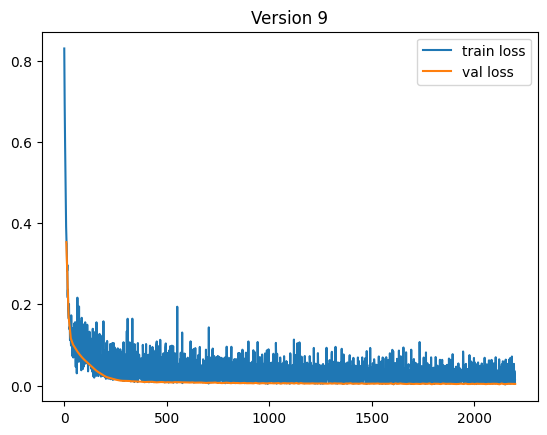

In [12]:
trainer = Trainer(
    enable_progress_bar=True,
    max_epochs=200,
    log_every_n_steps=1,
    logger=CSVLogger('.'),
    accelerator='cpu',
)
trainer.fit(
    model=model, 
    train_dataloaders=train_dataloader,
    val_dataloaders=val_dataloader,
)
plot_loss(trainer)

In [13]:
print_pred_cost(model, val_dataset, n_operations)

Problem 5,5,5-81: 5944.42
Problem 5,5,5-82: 5516.11
Problem 5,5,5-83: 7399.83
Problem 5,5,5-84: 6670.25
Problem 5,5,5-85: 6451.34
Problem 5,5,5-86: 6386.47
Problem 5,5,5-87: 7252.32
Problem 5,5,5-88: 6303.60
Problem 5,5,5-89: 7561.42
Problem 5,5,5-90: 6899.70
Problem 5,5,5-91: 6881.75
Problem 5,5,5-92: 6899.70
Problem 5,5,5-93: 5167.91
Problem 5,5,5-94: 7212.45
Problem 5,5,5-95: 5980.91
Problem 5,5,5-96: 5199.04
Problem 5,5,5-97: 5350.38
Problem 5,5,5-98: 5717.06
Problem 5,5,5-99: 6225.56
Problem 5,5,5-100: 6944.59
Average cost: 6398.24


## Model 5-10-10

In [46]:
n_tasks, n_operations, n_cities = 5, 10, 10
train_dataset, val_dataset = prepare_train_val_dataset(n_tasks, n_operations, n_cities)

In [47]:
check_feasibility_dataset(train_dataset, n_tasks, n_operations, n_cities)

Average cost: 7778.57


In [48]:
check_feasibility_dataset(val_dataset, n_tasks, n_operations, n_cities)

Average cost: 7645.43


In [20]:
train_graphs = prepare_graphs(train_dataset, n_tasks, n_operations, n_cities)
val_graphs = prepare_graphs(val_dataset, n_tasks, n_operations, n_cities)

train_graph_dataset = GraphDataset(train_graphs)
val_graph_dataset = GraphDataset(val_graphs)

train_dataloader = GraphDataLoader(train_graph_dataset, batch_size=8, shuffle=True)
val_dataloader = GraphDataLoader(val_graph_dataset, batch_size=100)

In [ ]:
model = GNN(
    ins_dim=1,
    ino_dim=n_operations,
    out_dim=32,
    n_layers=3,
    lr=0.002,
)
model

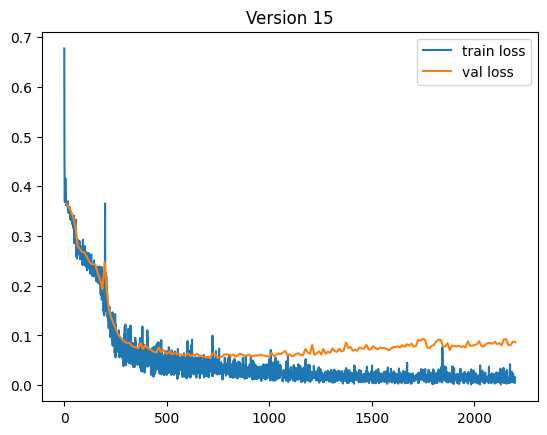

In [50]:
trainer = Trainer(
    enable_progress_bar=True,
    max_epochs=200,
    log_every_n_steps=1,
    logger=CSVLogger('.'),
    accelerator='cpu',
)
trainer.fit(
    model=model, 
    train_dataloaders=train_dataloader,
    val_dataloaders=val_dataloader,
)
plot_loss(trainer)

In [51]:
print_pred_cost(model, val_dataset, n_operations)

Problem 5,10,10-81: 6523.34
Problem 5,10,10-82: 7822.18
Problem 5,10,10-83: 9270.72
Problem 5,10,10-84: 8242.00
Problem 5,10,10-85: 8764.51
Problem 5,10,10-86: 9732.39
Problem 5,10,10-87: 7356.36
Problem 5,10,10-88: 7149.11
Problem 5,10,10-89: 11814.46
Problem 5,10,10-90: 7961.95
Problem 5,10,10-91: 10206.34
Problem 5,10,10-92: 9827.50
Problem 5,10,10-93: 7865.04
Problem 5,10,10-94: 9244.96
Problem 5,10,10-95: 7392.05
Problem 5,10,10-96: 10399.74
Problem 5,10,10-97: 10092.08
Problem 5,10,10-98: 8241.08
Problem 5,10,10-99: 8685.66
Problem 5,10,10-100: 7191.95
Average cost: 8689.17


## Model 10-10-10

In [49]:
n_tasks, n_operations, n_cities = 10, 10, 10
train_dataset, val_dataset = prepare_train_val_dataset(n_tasks, n_operations, n_cities)

In [50]:
check_feasibility_dataset(train_dataset, n_tasks, n_operations, n_cities)

Average cost: 15413.77


In [51]:
check_feasibility_dataset(val_dataset, n_tasks, n_operations, n_cities)

Average cost: 15464.60


In [24]:
train_graphs = prepare_graphs(train_dataset, n_tasks, n_operations, n_cities)
val_graphs = prepare_graphs(val_dataset, n_tasks, n_operations, n_cities)

train_graph_dataset = GraphDataset(train_graphs)
val_graph_dataset = GraphDataset(val_graphs)

train_dataloader = GraphDataLoader(train_graph_dataset, batch_size=8, shuffle=True)
val_dataloader = GraphDataLoader(val_graph_dataset, batch_size=100)

In [34]:
model = GNN(
    ins_dim=1,
    ino_dim=n_operations,
    out_dim=32,
    n_layers=3,
    lr=0.002,
)
model

GNN(
  (convs): ModuleList(
    (0): AttnConvLayer(
      (W_s): Linear(in_features=1, out_features=32, bias=True)
      (W_os): Linear(in_features=12, out_features=32, bias=True)
      (W_ss): Linear(in_features=2, out_features=32, bias=True)
      (attn): Linear(in_features=64, out_features=1, bias=True)
      (W_in): Linear(in_features=10, out_features=32, bias=True)
      (W_self): Linear(in_features=10, out_features=32, bias=True)
      (W_out): Linear(in_features=10, out_features=32, bias=True)
      (W_o): Linear(in_features=96, out_features=32, bias=True)
    )
    (1-2): 2 x AttnConvLayer(
      (W_s): Linear(in_features=32, out_features=32, bias=True)
      (W_os): Linear(in_features=34, out_features=32, bias=True)
      (W_ss): Linear(in_features=33, out_features=32, bias=True)
      (attn): Linear(in_features=64, out_features=1, bias=True)
      (W_in): Linear(in_features=32, out_features=32, bias=True)
      (W_self): Linear(in_features=32, out_features=32, bias=True)
    

In [35]:
trainer = Trainer(
    enable_progress_bar=True,
    max_epochs=200,
    log_every_n_steps=1,
    logger=CSVLogger('.'),
    accelerator='cpu',
)
trainer.fit(
    model=model, 
    train_dataloaders=train_dataloader,
    val_dataloaders=val_dataloader,
)
plot_loss(trainer)

GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/vitaliypozdnyakov/miniconda3/envs/gnn/lib/python3.10/site-packages/pytorch_lightning/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.

  | Name    | Type              | Params | Mode 
------------------------------------------------------
0 | convs   | ModuleList        | 24.0 K | train
1 | dropout | Dropout           | 0      | train
2 | dec     | DotProductDecoder | 0      | train
------------------------------------------------------
24.0 K    Trainable params
0         Non-trainable params
24.0 K    Total params
0.096     Total estimated model params size (MB)
30        Modules in train mode
0         Modules in eval mode


Sanity Checking: |                                                                                           |…

/Users/vitaliypozdnyakov/miniconda3/envs/gnn/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:424: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
/Users/vitaliypozdnyakov/miniconda3/envs/gnn/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:424: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Training: |                                                                                                  |…

Validation: |                                                                                                |…

...

Validation: |                                                                                                |…

Validation: |                                                                                                |…

Validation: |                                                                                                |…

Validation: |                                                                                                |…

Validation: |                                                                                                |…

In [39]:
print_pred_cost(model, val_dataset, n_operations)

Problem 10,10,10-81: 21228.42
Problem 10,10,10-82: 20946.06
Problem 10,10,10-83: 14897.04
Problem 10,10,10-84: 17509.65
Problem 10,10,10-85: 17235.21
Problem 10,10,10-86: 17569.17
Problem 10,10,10-87: 15242.38
Problem 10,10,10-88: 13149.94
Problem 10,10,10-89: 18398.41
Problem 10,10,10-90: 19575.46
Problem 10,10,10-91: 15484.12
Problem 10,10,10-92: 15412.70
Problem 10,10,10-93: 20868.39
Problem 10,10,10-94: 15896.32
Problem 10,10,10-95: 17467.75
Problem 10,10,10-96: 16473.37
Problem 10,10,10-97: 16775.81
Problem 10,10,10-98: 17182.50
Problem 10,10,10-99: 18323.65
Problem 10,10,10-100: 16759.21
Average cost: 17319.78


## Model 5-10-20

In [52]:
n_tasks, n_operations, n_cities = 5, 10, 20
train_dataset, val_dataset = prepare_train_val_dataset(n_tasks, n_operations, n_cities)

In [53]:
check_feasibility_dataset(train_dataset, n_tasks, n_operations, n_cities)

Average cost: 5996.54


In [54]:
check_feasibility_dataset(val_dataset, n_tasks, n_operations, n_cities)

Average cost: 5971.48


In [55]:
train_graphs = prepare_graphs(train_dataset, n_tasks, n_operations, n_cities)
val_graphs = prepare_graphs(val_dataset, n_tasks, n_operations, n_cities)

train_graph_dataset = GraphDataset(train_graphs)
val_graph_dataset = GraphDataset(val_graphs)

train_dataloader = GraphDataLoader(train_graph_dataset, batch_size=8, shuffle=True)
val_dataloader = GraphDataLoader(val_graph_dataset, batch_size=100)

In [66]:
model = GNN(
    ins_dim=1,
    ino_dim=n_operations,
    out_dim=32,
    n_layers=3,
    lr=0.002,
)
model

GNN(
  (convs): ModuleList(
    (0): AttnConvLayer(
      (W_s): Linear(in_features=1, out_features=32, bias=True)
      (W_os): Linear(in_features=12, out_features=32, bias=True)
      (W_ss): Linear(in_features=2, out_features=32, bias=True)
      (attn): Linear(in_features=64, out_features=1, bias=True)
      (W_in): Linear(in_features=10, out_features=32, bias=True)
      (W_self): Linear(in_features=10, out_features=32, bias=True)
      (W_out): Linear(in_features=10, out_features=32, bias=True)
      (W_o): Linear(in_features=96, out_features=32, bias=True)
    )
    (1-2): 2 x AttnConvLayer(
      (W_s): Linear(in_features=32, out_features=32, bias=True)
      (W_os): Linear(in_features=34, out_features=32, bias=True)
      (W_ss): Linear(in_features=33, out_features=32, bias=True)
      (attn): Linear(in_features=64, out_features=1, bias=True)
      (W_in): Linear(in_features=32, out_features=32, bias=True)
      (W_self): Linear(in_features=32, out_features=32, bias=True)
    

GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/vitaliypozdnyakov/miniconda3/envs/gnn/lib/python3.10/site-packages/pytorch_lightning/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.

  | Name    | Type              | Params | Mode 
------------------------------------------------------
0 | convs   | ModuleList        | 24.0 K | train
1 | dropout | Dropout           | 0      | train
2 | dec     | DotProductDecoder | 0      | train
------------------------------------------------------
24.0 K    Trainable params
0         Non-trainable params
24.0 K    Total params
0.096     Total estimated model params size (MB)
30        Modules in train mode
0         Modules in eval mode


Sanity Checking: |                                                                                           |…

/Users/vitaliypozdnyakov/miniconda3/envs/gnn/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:424: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
/Users/vitaliypozdnyakov/miniconda3/envs/gnn/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:424: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Training: |                                                                                                  |…

Validation: |                                                                                                |…

...

Validation: |                                                                                                |…

Validation: |                                                                                                |…

Validation: |                                                                                                |…

Validation: |                                                                                                |…

`Trainer.fit` stopped: `max_epochs=200` reached.


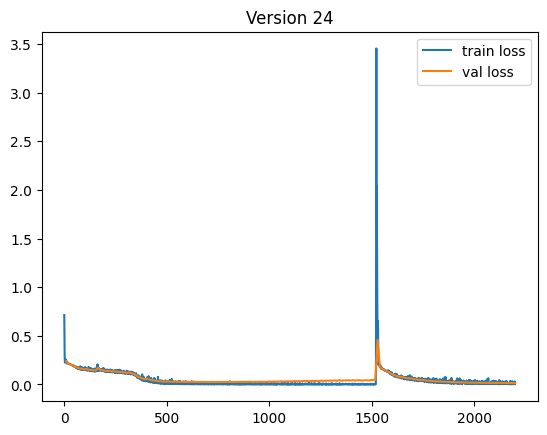

In [67]:
trainer = Trainer(
    enable_progress_bar=True,
    max_epochs=200,
    log_every_n_steps=1,
    logger=CSVLogger('.'),
    accelerator='cpu',
)
trainer.fit(
    model=model, 
    train_dataloaders=train_dataloader,
    val_dataloaders=val_dataloader,
)
plot_loss(trainer)

In [68]:
print_pred_cost(model, val_dataset, n_operations)

Problem 5,10,20-81: 6298.45
Problem 5,10,20-82: 6061.09
Problem 5,10,20-83: 6082.10
Problem 5,10,20-84: 7897.04
Problem 5,10,20-85: 6504.63
Problem 5,10,20-86: 7860.51
Problem 5,10,20-87: 5681.04
Problem 5,10,20-88: 5508.01
Problem 5,10,20-89: 5331.45
Problem 5,10,20-90: 6444.63
Problem 5,10,20-91: 7140.59
Problem 5,10,20-92: 8041.27
Problem 5,10,20-93: 6679.74
Problem 5,10,20-94: 5930.30
Problem 5,10,20-95: 5982.21
Problem 5,10,20-96: 5649.97
Problem 5,10,20-97: 6829.37
Problem 5,10,20-98: 6998.81
Problem 5,10,20-99: 6631.30
Problem 5,10,20-100: 6212.47
Average cost: 6488.25


## Model 5-20-10

In [69]:
n_tasks, n_operations, n_cities = 5, 20, 10
train_dataset, val_dataset = prepare_train_val_dataset(n_tasks, n_operations, n_cities)

In [70]:
check_feasibility_dataset(train_dataset, n_tasks, n_operations, n_cities)

Average cost: 17079.14


In [71]:
check_feasibility_dataset(val_dataset, n_tasks, n_operations, n_cities)

Average cost: 17094.43


In [72]:
train_graphs = prepare_graphs(train_dataset, n_tasks, n_operations, n_cities)
val_graphs = prepare_graphs(val_dataset, n_tasks, n_operations, n_cities)

train_graph_dataset = GraphDataset(train_graphs)
val_graph_dataset = GraphDataset(val_graphs)

train_dataloader = GraphDataLoader(train_graph_dataset, batch_size=8, shuffle=True)
val_dataloader = GraphDataLoader(val_graph_dataset, batch_size=100)

In [82]:
model = GNN(
    ins_dim=1,
    ino_dim=n_operations,
    out_dim=32,
    n_layers=4,
    lr=0.002,
)
model

GNN(
  (convs): ModuleList(
    (0): AttnConvLayer(
      (W_s): Linear(in_features=1, out_features=32, bias=True)
      (W_os): Linear(in_features=22, out_features=32, bias=True)
      (W_ss): Linear(in_features=2, out_features=32, bias=True)
      (attn): Linear(in_features=64, out_features=1, bias=True)
      (W_in): Linear(in_features=20, out_features=32, bias=True)
      (W_self): Linear(in_features=20, out_features=32, bias=True)
      (W_out): Linear(in_features=20, out_features=32, bias=True)
      (W_o): Linear(in_features=96, out_features=32, bias=True)
    )
    (1-3): 3 x AttnConvLayer(
      (W_s): Linear(in_features=32, out_features=32, bias=True)
      (W_os): Linear(in_features=34, out_features=32, bias=True)
      (W_ss): Linear(in_features=33, out_features=32, bias=True)
      (attn): Linear(in_features=64, out_features=1, bias=True)
      (W_in): Linear(in_features=32, out_features=32, bias=True)
      (W_self): Linear(in_features=32, out_features=32, bias=True)
    

GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/vitaliypozdnyakov/miniconda3/envs/gnn/lib/python3.10/site-packages/pytorch_lightning/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.

  | Name    | Type              | Params | Mode 
------------------------------------------------------
0 | convs   | ModuleList        | 34.9 K | train
1 | dropout | Dropout           | 0      | train
2 | dec     | DotProductDecoder | 0      | train
------------------------------------------------------
34.9 K    Trainable params
0         Non-trainable params
34.9 K    Total params
0.140     Total estimated model params size (MB)
39        Modules in train mode
0         Modules in eval mode


Sanity Checking: |                                                                                           |…

/Users/vitaliypozdnyakov/miniconda3/envs/gnn/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:424: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
/Users/vitaliypozdnyakov/miniconda3/envs/gnn/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:424: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Training: |                                                                                                  |…

Validation: |                                                                                                |…

...

Validation: |                                                                                                |…

Validation: |                                                                                                |…

Validation: |                                                                                                |…

Validation: |                                                                                                |…

`Trainer.fit` stopped: `max_epochs=100` reached.


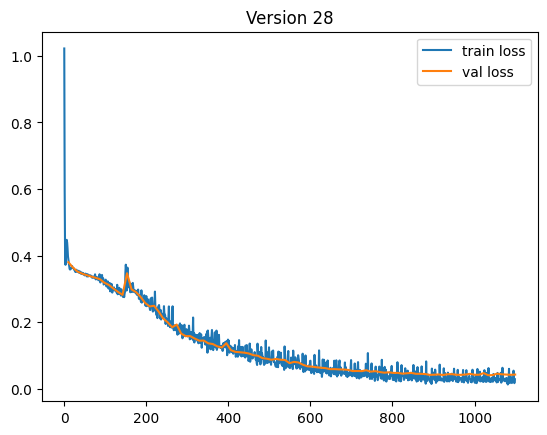

In [83]:
trainer = Trainer(
    enable_progress_bar=True,
    max_epochs=100,
    log_every_n_steps=1,
    logger=CSVLogger('.'),
    accelerator='cpu',
)
trainer.fit(
    model=model, 
    train_dataloaders=train_dataloader,
    val_dataloaders=val_dataloader,
)
plot_loss(trainer)

In [84]:
print_pred_cost(model, val_dataset, n_operations)

Problem 5,20,10-81: 19608.45
Problem 5,20,10-82: 18750.51
Problem 5,20,10-83: 17487.09
Problem 5,20,10-84: 17675.69
Problem 5,20,10-85: 18611.63
Problem 5,20,10-86: 19231.27
Problem 5,20,10-87: 18098.53
Problem 5,20,10-88: 17121.60
Problem 5,20,10-89: 18411.85
Problem 5,20,10-90: 17941.73
Problem 5,20,10-91: 18094.82
Problem 5,20,10-92: 16708.26
Problem 5,20,10-93: 17661.03
Problem 5,20,10-94: 16976.61
Problem 5,20,10-95: 18836.17
Problem 5,20,10-96: 17936.54
Problem 5,20,10-97: 17475.79
Problem 5,20,10-98: 18939.83
Problem 5,20,10-99: 18011.43
Problem 5,20,10-100: 18278.01
Average cost: 18092.84


## Model 5-20-20

In [85]:
n_tasks, n_operations, n_cities = 5, 20, 20
train_dataset, val_dataset = prepare_train_val_dataset(n_tasks, n_operations, n_cities)

In [86]:
check_feasibility_dataset(train_dataset, n_tasks, n_operations, n_cities)

Average cost: 14287.80


In [87]:
check_feasibility_dataset(val_dataset, n_tasks, n_operations, n_cities)

Average cost: 14313.24


In [88]:
train_graphs = prepare_graphs(train_dataset, n_tasks, n_operations, n_cities)
val_graphs = prepare_graphs(val_dataset, n_tasks, n_operations, n_cities)

train_graph_dataset = GraphDataset(train_graphs)
val_graph_dataset = GraphDataset(val_graphs)

train_dataloader = GraphDataLoader(train_graph_dataset, batch_size=8, shuffle=True)
val_dataloader = GraphDataLoader(val_graph_dataset, batch_size=100)

In [98]:
model = GNN(
    ins_dim=1,
    ino_dim=n_operations,
    out_dim=32,
    n_layers=4,
    lr=0.002,
)
model

GNN(
  (convs): ModuleList(
    (0): AttnConvLayer(
      (W_s): Linear(in_features=1, out_features=32, bias=True)
      (W_os): Linear(in_features=22, out_features=32, bias=True)
      (W_ss): Linear(in_features=2, out_features=32, bias=True)
      (attn): Linear(in_features=64, out_features=1, bias=True)
      (W_in): Linear(in_features=20, out_features=32, bias=True)
      (W_self): Linear(in_features=20, out_features=32, bias=True)
      (W_out): Linear(in_features=20, out_features=32, bias=True)
      (W_o): Linear(in_features=96, out_features=32, bias=True)
    )
    (1-3): 3 x AttnConvLayer(
      (W_s): Linear(in_features=32, out_features=32, bias=True)
      (W_os): Linear(in_features=34, out_features=32, bias=True)
      (W_ss): Linear(in_features=33, out_features=32, bias=True)
      (attn): Linear(in_features=64, out_features=1, bias=True)
      (W_in): Linear(in_features=32, out_features=32, bias=True)
      (W_self): Linear(in_features=32, out_features=32, bias=True)
    

GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/vitaliypozdnyakov/miniconda3/envs/gnn/lib/python3.10/site-packages/pytorch_lightning/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.

  | Name    | Type              | Params | Mode 
------------------------------------------------------
0 | convs   | ModuleList        | 34.9 K | train
1 | dropout | Dropout           | 0      | train
2 | dec     | DotProductDecoder | 0      | train
------------------------------------------------------
34.9 K    Trainable params
0         Non-trainable params
34.9 K    Total params
0.140     Total estimated model params size (MB)
39        Modules in train mode
0         Modules in eval mode


Sanity Checking: |                                                                                           |…

/Users/vitaliypozdnyakov/miniconda3/envs/gnn/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:424: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
/Users/vitaliypozdnyakov/miniconda3/envs/gnn/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:424: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Training: |                                                                                                  |…

Validation: |                                                                                                |…

...

Validation: |                                                                                                |…

Validation: |                                                                                                |…

Validation: |                                                                                                |…

Validation: |                                                                                                |…

`Trainer.fit` stopped: `max_epochs=200` reached.


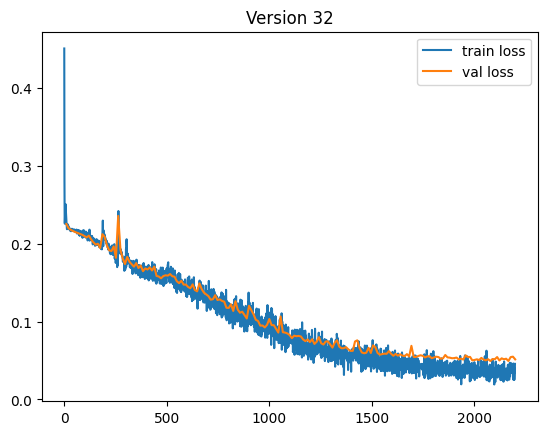

In [99]:
trainer = Trainer(
    enable_progress_bar=True,
    max_epochs=200,
    log_every_n_steps=1,
    logger=CSVLogger('.'),
    accelerator='cpu',
)
trainer.fit(
    model=model, 
    train_dataloaders=train_dataloader,
    val_dataloaders=val_dataloader,
)
plot_loss(trainer)

In [100]:
print_pred_cost(model, val_dataset, n_operations)

Problem 5,20,20-81: 17688.99
Problem 5,20,20-82: 17874.99
Problem 5,20,20-83: 18607.00
Problem 5,20,20-84: 20581.44
Problem 5,20,20-85: 16506.06
Problem 5,20,20-86: 16920.47
Problem 5,20,20-87: 18715.94
Problem 5,20,20-88: 15993.00
Problem 5,20,20-89: 20019.08
Problem 5,20,20-90: 17729.45
Problem 5,20,20-91: 18917.45
Problem 5,20,20-92: 18563.31
Problem 5,20,20-93: 17847.57
Problem 5,20,20-94: 17074.03
Problem 5,20,20-95: 16066.06
Problem 5,20,20-96: 17080.27
Problem 5,20,20-97: 17074.73
Problem 5,20,20-98: 17776.16
Problem 5,20,20-99: 19772.24
Problem 5,20,20-100: 16980.32
Average cost: 17889.43
